In [2]:
#%pip install qiskit-aer


In [3]:

import numpy as np
import qiskit
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import SamplerV2


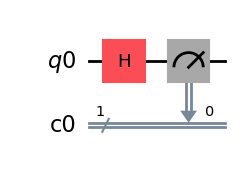

In [4]:
qr = QuantumRegister(1)
cr = ClassicalRegister(1)
qc = QuantumCircuit(qr, cr)
qc.h(qr[0])
qc.measure(qr, cr)

qc.draw('mpl')

In [9]:
Simulator = AerSimulator()
result = Simulator.run(qc, memory=True).result()
result_shots = result.get_counts(qc)
print(result_shots)

{'0': 508, '1': 516}


## Generate random numbers using AerSimulator()

In [10]:
n_bits = 8
n_rand_nums = 10
results_dict = {}
results_dict['str'] = []
results_dict['int'] = []

Simulator = AerSimulator()

for _ in range(n_rand_nums):
    result = Simulator.run(qc, shots=n_bits, memory=True).result()
    result_shots = [(ele[2]) for ele in result.data().get('memory')]
    result_str = ''.join(result_shots)
    results_dict['str'].append(result_str)
    results_dict['int'].append(int(result_str, 2))

#results_n = list(zip(results_dict['str'], results_dict['int']))
#print(results_n)
print('\n generated random numbers: ', results_dict['int'])


 generated random numbers:  [167, 185, 106, 169, 217, 103, 42, 199, 5, 156]


## Generate random numbers using Sampler. AerSimulator() as backend

In [15]:
n_bits = 8
n_rand_nums = 10

results_dict = {}
results_dict['str'] = []
results_dict['int'] = []

backend = AerSimulator()
Sampler = SamplerV2(mode=backend)
for _ in range(n_rand_nums):
    result = Sampler.run([qc], shots=n_bits).result()
    result_shots = result[0].data.c0.to_bool_array()
    result_char = [str(int(ele[0])) for ele in result_shots]
    result_str = ''.join(result_char)
    result_int = int(result_str, 2)
    results_dict['str'].append(result_str)
    results_dict['int'].append(result_int)

results_n = list(zip(results_dict['str'], results_dict['int']))
print(results_n)
print('\n generated random numbers: ', results_dict['int'])


[('00001010', 10), ('01001010', 74), ('11111000', 248), ('01110000', 112), ('10000111', 135), ('00110110', 54), ('10010010', 146), ('00100111', 39), ('00110100', 52), ('01010111', 87)]

 generated random numbers:  [10, 74, 248, 112, 135, 54, 146, 39, 52, 87]


In [ ]:
int(result_shots[0][0])

1

In [19]:
dir(result[0].data.c0)

['__abstractmethods__',
 '__and__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__invert__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__or__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '__xor__',
 '_abc_impl',
 '_array',
 '_bytes_to_bitstring',
 '_bytes_to_int',
 '_get_counts',
 '_is_protocol',
 '_is_runtime_protocol',
 '_num_bits',
 '_prepare_broadcastable',
 '_shape',
 'array',
 'bitcount',
 'concatenate',
 'concatenate_bits',
 'concatenate_shots',
 'expectation_values',
 'from_bool_array',
 'from_counts',
 'from_samples',
 'get_bitstrings',
 'get_counts',
 'get_int_counts',
 'ndim',
 'num_bits',
 'num_shots',
 'postselect',
 'reshape

In [18]:
dir(result[0].data)

['_FIELDS',
 '_FIELD_TYPES',
 '_RESTRICTED_NAMES',
 '_SHAPE',
 '__abstractmethods__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_data',
 '_is_protocol',
 '_is_runtime_protocol',
 '_shape',
 'c0',
 'items',
 'keys',
 'ndim',
 'shape',
 'size',
 'values']

In [17]:
result[0].data.c0.num_shots

8